In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)


2025-10-03 16:27:27.096852: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-03 16:27:27.097138: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-03 16:27:27.147066: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-03 16:27:29.167674: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

## load mdata

In [2]:
path = r"/ix1/ylee/Yifan_Zhang/Code_data/data_EAE/external_EAE/GSE188320/GSE188320_batch6_9_gex_tcr_mvTCR.h5mu"
mdata = mu.read(path)
mdata

MuData object with n_obs × n_vars = 39845 × 27998
  2 modalities
    gex:	39845 x 27998
      obs:	'batch', 'condition', 'mouse_id', 'assignment_demuxem'
    airr:	39845 x 0
      obsm:	'airr'

In [3]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

# by nucleotide acid seq
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
# ir.tl.clonotype_network(mdata, min_cells=10)

In [4]:
meta_airr = ir.get.airr(mdata['airr'], ["cdr3_aa", "v_call", "j_call"] ,  ('VJ_1', 'VDJ_1'))
mdata.obs = mdata.obs.join(meta_airr)

# mdata.obs = mdata.obs.reindex(mdata.mod['gex'].obs.index)
mdata

MuData object with n_obs × n_vars = 39845 × 27998
  obs:	'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call'
  2 modalities
    gex:	39845 x 27998
      obs:	'batch', 'condition', 'mouse_id', 'assignment_demuxem'
    airr:	39845 x 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'

In [6]:
mdata['gex'].obs = mdata['gex'].obs.rename(columns={'assignment_demuxem': 'tissue'})

## MOG and 2D2 difference

## clonotype dist

In [7]:
# select cells appear in both CNS and SPL

# thresh on clono size
clone_thresh = 2
mdata.obs['cloned'] = mdata['airr'].obs['clone_id_size'] >= clone_thresh

# Check if appear in two tissues
mdata_cloned = mdata[mdata.obs['cloned']]
clone_tissue_df = mdata_cloned['airr'].obs[['clone_id']].join(mdata_cloned['gex'].obs['tissue'])
clone_tissue_counts = clone_tissue_df.groupby('clone_id')['tissue'].nunique()
multi_tissue_clones = clone_tissue_counts[clone_tissue_counts > 1].index
mdata.obs['in_two_tissue'] = mdata['airr'].obs['clone_id'].isin(multi_tissue_clones)

mdata.obs['in_two_tissue'].value_counts()

in_two_tissue
True     22088
False    17757
Name: count, dtype: int64

## 2D2 TCR dist

In [9]:
from tcrdist.repertoire import TCRrep
# formating by tcrdist requirements
ref_df = pd.read_csv(r'/ihome/ylee/yiz133/Code/Data processing/data/TCRdist/std_MOG_assays.csv')
ref_df.rename(columns={'Chain 2 CDR3': 'cdr3_b_aa', 'Chain 2 V Gene':'v_b_gene', 
                   'Chain 2 J Gene':'j_b_gene', }, inplace=True)

ref_df['v_b_gene'] = ref_df['v_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')
ref_df['j_b_gene'] = ref_df['j_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')


In [10]:
def mdata_TCR_formating(mdata_subset):
    query_df = mdata_subset.obs[['VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call']]
    query_df['cell_id'] = query_df.index
    query_df.dropna(subset = ["VDJ_1_cdr3_aa"])

    query_df.rename(columns={'VDJ_1_cdr3_aa': 'cdr3_b_aa', 'VDJ_1_v_call':'v_b_gene', 
                       'VDJ_1_j_call':'j_b_gene', }, inplace=True)

    # 'VDJ_1_consensus_count':'count'
    # query_df['cdr3_b_aa'] = 'C' + query_df['cdr3_b_aa'].astype(str) + 'F'
    query_df['cdr3_b_aa'] = query_df['cdr3_b_aa'].astype(str)
    
    query_df['v_b_gene'] = query_df['v_b_gene'].str.split('+').str[0]
    query_df['j_b_gene'] = query_df['j_b_gene'].str.split('+').str[0]

    query_df['v_b_gene'] = query_df['v_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')
    query_df['j_b_gene'] = query_df['j_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')

    # query_df_clones = query_df_clones.drop(columns=["cell_id"])
    query_df_unique = query_df.drop_duplicates(['cdr3_b_aa'])
    return query_df_unique


In [11]:
def TCRdist_to_ref(ref_df, query_df_unique):
    tr_ref = TCRrep(cell_df = ref_df, 
                organism = 'mouse', 
                chains = ['beta'],
                compute_distances = False,)

    tr_q = TCRrep(cell_df = query_df_unique, 
                organism = 'mouse', 
                chains = ['beta'],
                compute_distances = False,)

    tr_ref.compute_rect_distances(tr_ref.clone_df,  tr_q.clone_df)
    print(tr_ref.rw_beta.shape)
    print(tr_ref.rw_beta)
    return tr_ref, tr_q


(25, 8882)
[[ 80 118  36 ... 113 118 164]
 [101 106  60 ... 125 130 164]
 [ 98 118  78 ... 137 100 176]
 ...
 [ 68 118  36 ... 101 118 164]
 [ 68 106  48 ... 113 118 176]
 [ 74 142  42 ... 113 124 176]]
(25, 1875)
[[ 36  97  91 ... 114  90 140]
 [ 60 133 127 ... 114 114 116]
 [ 78 133 133 ... 120 138 116]
 ...
 [ 36  85  91 ... 111  90 128]
 [ 48  94  91 ... 114  90 140]
 [ 42  97  97 ... 102 114 140]]


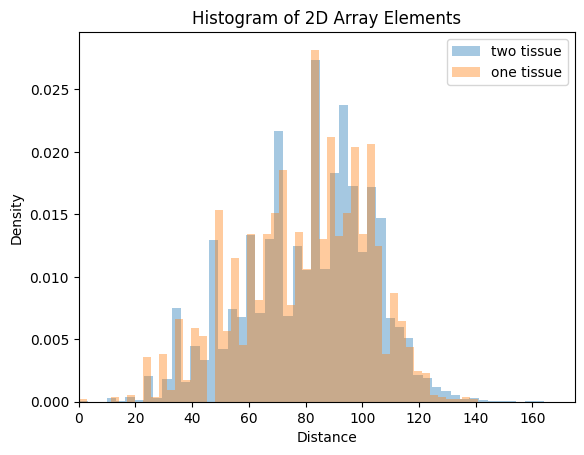

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

tr_list = []
dist_thres = 85
mdata_sub = mdata[mdata.obs['in_two_tissue']]

m_list = [mdata, mdata_sub]
tcrDist_list = []

for mdata_sub in m_list:
    # 'in_two_tissue' ,  'cloned'
    query_df = mdata_TCR_formating(mdata_sub)

    tr_out, tr_query = TCRdist_to_ref(ref_df, query_df)
    tr_list.append(tr_out)

    flat_arr = tr_out.rw_beta.min(axis=0).flatten()
    TCR_all = tr_query.clone_df
    TCR_all['TCRdist_MOG'] = flat_arr
    
    tcrDist_list.append(TCR_all)
    plt.hist(flat_arr, bins=50, density=True, alpha=0.4)
    selected_clone_id = flat_arr < dist_thres
    TCR_selected = TCR_all[selected_clone_id]
    
plt.xlim([0, 175])
plt.legend(['two tissue', 'one tissue'])
plt.title("Histogram of 2D Array Elements")
plt.xlabel("Distance")
plt.ylabel("Density")
plt.show()    

In [13]:
TCR_all = tcrDist_list[0]
sub_2d2 = TCR_all[TCR_all['cdr3_b_aa']=='ASSLDCGANP']
sub_2d2

,cdr3_b_aa,v_b_gene,j_b_gene,cdr1_b_aa,cdr2_b_aa,pmhc_b_aa,count,clone_id,TCRdist_MOG


In [14]:
#### 2D2 seq not found in EAE TCR repertoire   #####

In [15]:
mdata.obs = (
    mdata.obs.merge(
        TCR_all[['cdr3_b_aa', 'TCRdist_MOG']],
        how='left',
        left_on='VDJ_1_cdr3_aa',
        right_on='cdr3_b_aa'
    )
    .drop(columns=['cdr3_b_aa'])
    .set_index(mdata.obs.index)   # restore original index
)

mdata.obs['TCRdist_MOG']

AAACCTGAGAGTCGGT-1-b6m1     68.0
AAACCTGAGGCTCAGA-1-b6m1     93.0
AAACCTGCAATAGCAA-1-b6m1    104.0
AAACCTGCAGTCTTCC-1-b6m1     84.0
AAACCTGCATTCTTAC-1-b6m1     84.0
                           ...  
TTTGGTTTCGCTTAGA-1-b9m2     82.0
TTTGTCAAGTATCTCG-1-b9m2     89.0
TTTGTCAGTCGCATCG-1-b9m2     76.0
TTTGTCAGTTTGTGTG-1-b9m2    108.0
TTTGTCATCCTGCTTG-1-b9m2     54.0
Name: TCRdist_MOG, Length: 39845, dtype: float64

In [16]:
aa

NameError: name 'aa' is not defined

In [ ]:
### save data   ###
mdata.write('all_common_DE2500_metmdata.h5mu')

In [ ]:
groups = ['True', 'False']
sc.tl.rank_genes_groups(mdata_sub['gex'], groupby = group_name, groups=groups, method="wilcoxon")
df = sc.get.rank_genes_groups_df(mdata_sub['gex'], group = 'True')


In [ ]:
sc.pl.rank_genes_groups_dotplot(mdata_sub['gex'], groupby=group_name, groups=groups,
                                    cmap='Blues')
# var_names=markers_in,

In [ ]:
df_true = df.head(10)
df_true

In [ ]:
df_false = sc.get.rank_genes_groups_df(mdata_sub['gex'], group = 'False').head(10)
df_false

In [ ]:
pval_type = df[df["names"].isin(type_markers)]
pval_type["gene"] = pd.Categorical(pval_type["names"], categories=type_markers, ordered=True)
pval_type = pval_type.sort_values("gene")
pval_type

In [ ]:
var_group_positions = [(0,0), (1,3), (4, 7), (8, 9)]   # inclusive start, inclusive end
var_group_labels = ["CD4 T", "CD8 T", "Treg", "Th17"]

dp = sc.pl.dotplot(
    mdata_sub['gex'], var_names=type_markers, groupby=group_name, cmap="Blues",
    var_group_positions=var_group_positions,
    var_group_labels=var_group_labels,
    show=False, return_fig=True
)
dp.make_figure()

def p2stars(p):
    if p < 1e-4: return "****"
    elif p < 1e-3: return "***"
    elif p < 1e-2: return "**"
    elif p < 5e-2: return "*"
    else: return ""

    # dict (or Series) of p-values per gene (fill with yours)
pvals = dict(zip(pval_type['names'], pval_type['pvals'])) # example; replace with real p-values
ax = dp.get_axes()["mainplot_ax"]

# get current tick labels
yticklabels = [t.get_text() for t in ax.get_xticklabels()]

# prepend stars to gene names
new_labels = [f"{p2stars(pvals.get(g,1))}  {g}" for g in yticklabels]
ax.set_xticklabels(new_labels)
plt.show()

In [ ]:
pval_state = df[df["names"].isin(markers_in)]
pval_state["gene"] = pd.Categorical(pval_state["names"], categories=markers_in, ordered=True)
pval_state = pval_state.sort_values("gene")
pval_state

In [ ]:
var_group_positions = [(0,2), (3,5), (6,8), (9, 9)]   # inclusive start, inclusive end
var_group_labels = ["IFN stim", "act", "Exhaust", "Central mem"]

dp = sc.pl.dotplot(
    mdata_sub['gex'], var_names=markers_in, groupby=group_name, cmap="Blues",
    var_group_positions=var_group_positions,
    var_group_labels=var_group_labels,
    show=False, return_fig=True
)
dp.make_figure()

# dict (or Series) of p-values per gene (fill with yours)
pvals =  dict(zip(pval_state['names'], pval_state['pvals'])) # example; replace with real p-values

ax = dp.get_axes()["mainplot_ax"]

# get current tick labels
yticklabels = [t.get_text() for t in ax.get_xticklabels()]

# prepend stars to gene names
new_labels = [f"{p2stars(pvals.get(g,1))}  {g}" for g in yticklabels]
ax.set_xticklabels(new_labels)
plt.show()

In [ ]:
## subset by TCR dist
mdata_temp = mdata_temp[mdata_temp.obs['VDJ_1_cdr3_aa'].isin(TCR_selected['cdr3_b_aa_trimed'])]
mdata_temp                    

In [ ]:
# mdata_subset = mdata
import scanpy as sc
sc.pp.pca(mdata_temp["gex"], svd_solver="arpack", n_comps=10)
sc.pp.neighbors(mdata_temp["gex"], use_rep='X_pca', n_neighbors = 10)
sc.tl.umap(mdata_temp["gex"], min_dist=0.5, spread=1.0)
sc.tl.leiden(mdata_temp["gex"], resolution = 0.5, n_iterations=2, flavor = 'igraph')
sc.pl.umap(mdata_temp["gex"], color=["tissue"])

In [ ]:
mdata_temp.obs['manual_cell_type'] = mdata_temp.obs['manual_cell_type'].cat.remove_unused_categories()
mu.pl.embedding(mdata_temp, basis="gex:umap", color= ['manual_cell_type', 'gex:mouse_id'], wspace = 0.2, ncols=2, vmin=0)

In [ ]:
chemokine_all = [g for g in mdata_temp["gex"].var_names if g.startswith(("Cc", "Cxc", "Cx3c"))]

# markers_in = []
# for i in chemokine:
#     if i in mdata_subset["gex"].var_names:
#         markers_in.append(i) 

In [ ]:
sc.tl.rank_genes_groups(mdata_temp["gex"], groupby ="tissue",  method="wilcoxon")
# mask_var = chemokine_all,

# sc.pl.rank_genes_groups_heatmap(mdata_subset["gex"], groupby = "tissue", gene_symbols= chemokine_all,
#                                  cmap='bwr',)

In [ ]:
# Get results as DataFrame
df = sc.get.rank_genes_groups_df(mdata_temp["gex"], group="CN")

# Filter to certain genes
df_filtered = df[df["names"].isin(chemokine_all)]

print(df_filtered.head(5))

In [ ]:
chemokine_topDE = df_filtered['names'].head(10)

mu.pl.embedding(mdata_temp, basis="gex:umap", color= chemokine_topDE[:4], ncols=2, vmin=0)

In [ ]:
expr_chemokine = mdata['gex'][:, chemokine_topDE.values].to_df()
expr_chemokine

In [ ]:
type_markers = ['Cd4', 'Cd8a','Cd8b1','Nkg7','Foxp3', 'Ikzf2', 'Ctla4', 'Il2ra','Ccr6', 'Il22']
state_markers = ['Isg15', 'Gbp2', 'Ifih1', 'Icos', 'Cd69', 'Cd28', 'Pdcd1', 'Lag3', 'Havcr2', 'Ccr7', 'Sell', 'Cd27']
markers_in = []

for i in state_markers:
    if i in mdata["gex"].var_names:
        markers_in.append(i) 
markers_in
expr_markers = mdata['gex'][:, markers_in].to_df()
expr_markers.to_csv('marker_genes_for_training.csv')

In [ ]:
# expr_chemokine.to_csv('top10_chemok.csv')

In [ ]:
sc.pl.rank_genes_groups_dotplot(mdata_temp["gex"],  groupby="tissue", 
                                   var_names=chemokine_topDE[:10], cmap='Blues')


In [ ]:
vars_target_df = pd.read_csv('top10_chemok.csv')
sc.pl.rank_genes_groups_dotplot(mdata_temp["gex"],  groupby="tissue", 
                                   var_names=vars_target_df.columns[1:], cmap='Purples')    # 'Greens', 'Reds', 'Purples'


In [ ]:
TCR_matched = matrix[matrix['cdr3_b_aa'].isin(TCR_selected['cdr3_b_aa'])]
TCR_matched

In [ ]:
TCR_matched['manual_cell_type'].value_counts()

In [ ]:
TCR_matched['sample'].value_counts()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

EM_dim = 97
# max = 97
EM_matrix = TCR_matched.iloc[:,1:EM_dim]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(EM_matrix)

k = 10  # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42, copy_x=False)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=20, svd_solver='randomized', random_state=42)
X_pca_GIANA = pca.fit_transform(X_scaled)

import umap
umap = umap.UMAP(n_components=2, random_state=42, n_neighbors = 20, min_dist = 0.5)
# umap = umap.UMAP(n_components=2, random_state=42)

X_r = umap.fit_transform(X_pca_GIANA)

In [ ]:
# plot
import seaborn as sns

fig, axes = plt.subplots(2,2, figsize=(10,10))

# Create DataFrame
df = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': TCR_matched['sample']
})
sns.scatterplot(data=df, x='x', y='y', hue='label', s=10, ax = axes[0][0])

df2 = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': TCR_matched['manual_cell_type']
})
sns.scatterplot(data=df2, x='x', y='y', hue='label', s=10, ax = axes[0][1])

df3 = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': clusters
})
sns.scatterplot(data=df3, x='x', y='y', hue='label', s=10, palette="deep", ax = axes[1][0])


In [ ]:
%cd /ihome/ylee/yiz133/Code/deepTCR/unSupervised_cluster

In [ ]:
# Create a sample 2D matrix
matrix = pd.read_csv('DTCRU_extracted_features_96_0605.csv', sep = ',')
matrix.drop(columns={'Label'}, inplace=True)

matrix['CDR3_Beta'] = matrix['CDR3_Beta'].str[1:-1]

matrix = pd.merge(matrix, TCR_selected, left_on='CDR3_Beta', right_on='cdr3_b_aa', how='inner')

In [ ]:
m_right = mdata.obs[['VDJ_1_cdr3_aa','manual_cell_type','sample']]
m_right['BC'] = mdata.obs.index
deepTCR_matrix = pd.merge(matrix, m_right, left_on='CDR3_Beta', right_on = 'VDJ_1_cdr3_aa', how='inner')
deepTCR_matrix

In [ ]:
deepTCR_matrix['manual_cell_type'].value_counts()

In [ ]:
deepTCR_matrix['sample'].value_counts()

In [ ]:
EM_dim = 97
EM_matrix_deepTCR = deepTCR_matrix.iloc[:,3:EM_dim]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(EM_matrix_deepTCR)

k = 10  # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42, copy_x=False)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=20, svd_solver='randomized', random_state=42)

from sklearn.decomposition import KernelPCA
kpca = KernelPCA(n_components=30, kernel='rbf', gamma=0.1)

# generate features
# from sklearn.preprocessing import PolynomialFeatures
# poly = PolynomialFeatures(degree=2, include_bias=False)
# EM_matrix_deepTCR = poly.fit_transform(EM_matrix_deepTCR)

import umap
umap = umap.UMAP(n_components=2, random_state=42, n_neighbors = 20, min_dist = 0.5)
# umap = umap.UMAP(n_components=2, random_state=42)

# transform
X_pca_deepTCR = kpca.fit_transform(EM_matrix_deepTCR)
X_r = umap.fit_transform(X_pca_deepTCR)


In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Create DataFrame
df = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': deepTCR_matrix['sample']
})
sns.scatterplot(data=df, x='x', y='y', hue='label', s=30, ax = axes[0])

df2 = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': deepTCR_matrix['manual_cell_type']
})
sns.scatterplot(data=df2, x='x', y='y', hue='label', s=20, ax = axes[1])


In [ ]:
# GIANA emb
# M = matrix.copy()

# deepTCR emb
M = deepTCR_matrix.copy()
M_embs = M.iloc[:,3:99]
M_obs = M.drop(M.columns[3:99], axis=1)

kpca = KernelPCA(n_components=30, kernel='rbf', gamma=0.1)
M_embs = kpca.fit_transform(M_embs)

M_obs['tissue'] = M_obs['sample'].str[:3]

In [ ]:
import anndata as ad

mdata_embs = ad.AnnData(M_embs)
mdata_embs.obs = M_obs

mdata_embs

In [ ]:
sc.tl.rank_genes_groups(mdata_embs, groupby = "tissue", reference = 'SPL')
    
sc.pl.rank_genes_groups_violin(mdata_embs,  n_genes=5)

In [ ]:
aaa

In [ ]:
import decoupler as dc
dc.__version__

In [ ]:
aa
collectri = dc.op.collectri(organism="mouse")
ri_merged = collectri.groupby('source').agg({
    'weight': 'mean',         # average of numbers
    'target': lambda x: '|'.join(x)  # join with |
}).reset_index()

ri_merged

In [ ]:
# combined = df.groupby('col1')['col2'].sum()
# combined

In [ ]:
dc.mt.ulm(data=mdata['gex'], net=collectri)
score = dc.pp.get_obsm(mdata=mdata['gex'], key="score_ulm")

In [ ]:
score.obsm['score_ulm']

In [ ]:
tf = "Ar"
sc.pl.umap(score, color=[tf, "modified_cell_type"], cmap="RdBu_r", vcenter=0, title=[f"{tf} score", "celltype"])

In [ ]:
from sklearn.decomposition import PCA
import umap
import igraph as ig
import leidenalg

pca = PCA(n_components=25, random_state=42)
X_pca = pca.fit_transform(X_scaled)

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_pca)

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Compute the k-nearest neighbors
knn = NearestNeighbors(n_neighbors=15)
knn.fit(X_pca)
adj_matrix = knn.kneighbors_graph(X_pca, mode='connectivity')

In [ ]:
# Convert the adjacency matrix to a CSR format if it's not already
adj_csr = adj_matrix.tocsr()

# Create an igraph graph from the adjacency matrix
sources, targets = adj_csr.nonzero()
edges = list(zip(sources, targets))
g = ig.Graph(edges=edges, directed=False)


In [ ]:
partition = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition)
labels = np.array(partition.membership)


In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=10)
plt.title('UMAP Projection with Leiden Clustering')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.colorbar(scatter, label='Cluster')
plt.show()


In [ ]:
import anndata as ad
import scanpy as sc

EM_matrix = EM_matrix.dropna()
mdata = ad.AnnData(EM_matrix)
# mdata.obs['cluster'] = clusters
mdata.obs['tissue'] = tissue
mdata.obs['AA_seq'] = matrix.iloc[:,1]
mdata


In [ ]:
sc.pp.normalize_total(mdata)
sc.pp.log1p(mdata)


In [ ]:
np.isnan(mdata.X).any()

In [ ]:
nan_indices = np.argwhere(np.isnan(mdata.X))
nan_indices

In [ ]:
sc.pp.pca(mdata, svd_solver="arpack", n_comps=20)
sc.pp.neighbors(mdata["gex"], n_neighbors = 20)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)
sc.tl.leiden(mdata["gex"], resolution = 0.5, n_iterations=2, flavor = 'igraph')
sc.pl.umap(mdata["gex"], color=["leiden"])


In [ ]:
# mdata.write('TCRemb_2cluster.h5ad')